In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_curve, auc, roc_auc_score
)
from sklearn.utils import class_weight
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from imblearn.over_sampling import SMOTE

In [ ]:
from google.colab import files
uploaded = files.upload()
import io
filename = list(uploaded.keys())[0]
df_raw = pd.read_excel(io.BytesIO(uploaded[filename]))
print(f"✅ Dataset loaded: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print(df_raw.head())

Saving E comm.xlsx to E comm (2).xlsx
✅ Dataset loaded: 5630 rows × 20 columns
   CustomerID  Churn  Tenure PreferredLoginDevice  CityTier  WarehouseToHome  \
0       50001      1     4.0         Mobile Phone         3              6.0   
1       50002      1     NaN                Phone         1              8.0   
2       50003      1     NaN                Phone         1             30.0   
3       50004      1     0.0                Phone         3             15.0   
4       50005      1     0.0                Phone         1             12.0   

  PreferredPaymentMode  Gender  HourSpendOnApp  NumberOfDeviceRegistered  \
0           Debit Card  Female             3.0                         3   
1                  UPI    Male             3.0                         4   
2           Debit Card    Male             2.0                         4   
3           Debit Card    Male             2.0                         4   
4                   CC    Male             NaN              

In [ ]:
df = df_raw.copy()

# Standardise inconsistent category labels
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace(
    {'CC': 'Credit Card', 'Cash on Delivery': 'COD'}
)
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace({'Mobile': 'Mobile Phone'})

# Fill numeric nulls with median (production-safe, no data leakage)
numeric_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
                'OrderAmountHikeFromlastYear', 'CouponUsed',
                'OrderCount', 'DaySinceLastOrder']
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Encode categorical columns
cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode',
            'Gender', 'PreferedOrderCat', 'MaritalStatus']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("✅ Preprocessing complete.")
print(f"   Missing values remaining: {df.isnull().sum().sum()}")
print(f"   Churn rate: {df['Churn'].mean()*100:.1f}%")

✅ Preprocessing complete.
   Missing values remaining: 0
   Churn rate: 16.8%


/tmp/ipykernel_624/2398349480.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


/tmp/ipykernel_624/689378486.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_plot['Tenure'].fillna(df_plot['Tenure'].median(), inplace=True)
/tmp/ipykernel_624/689378486.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot(


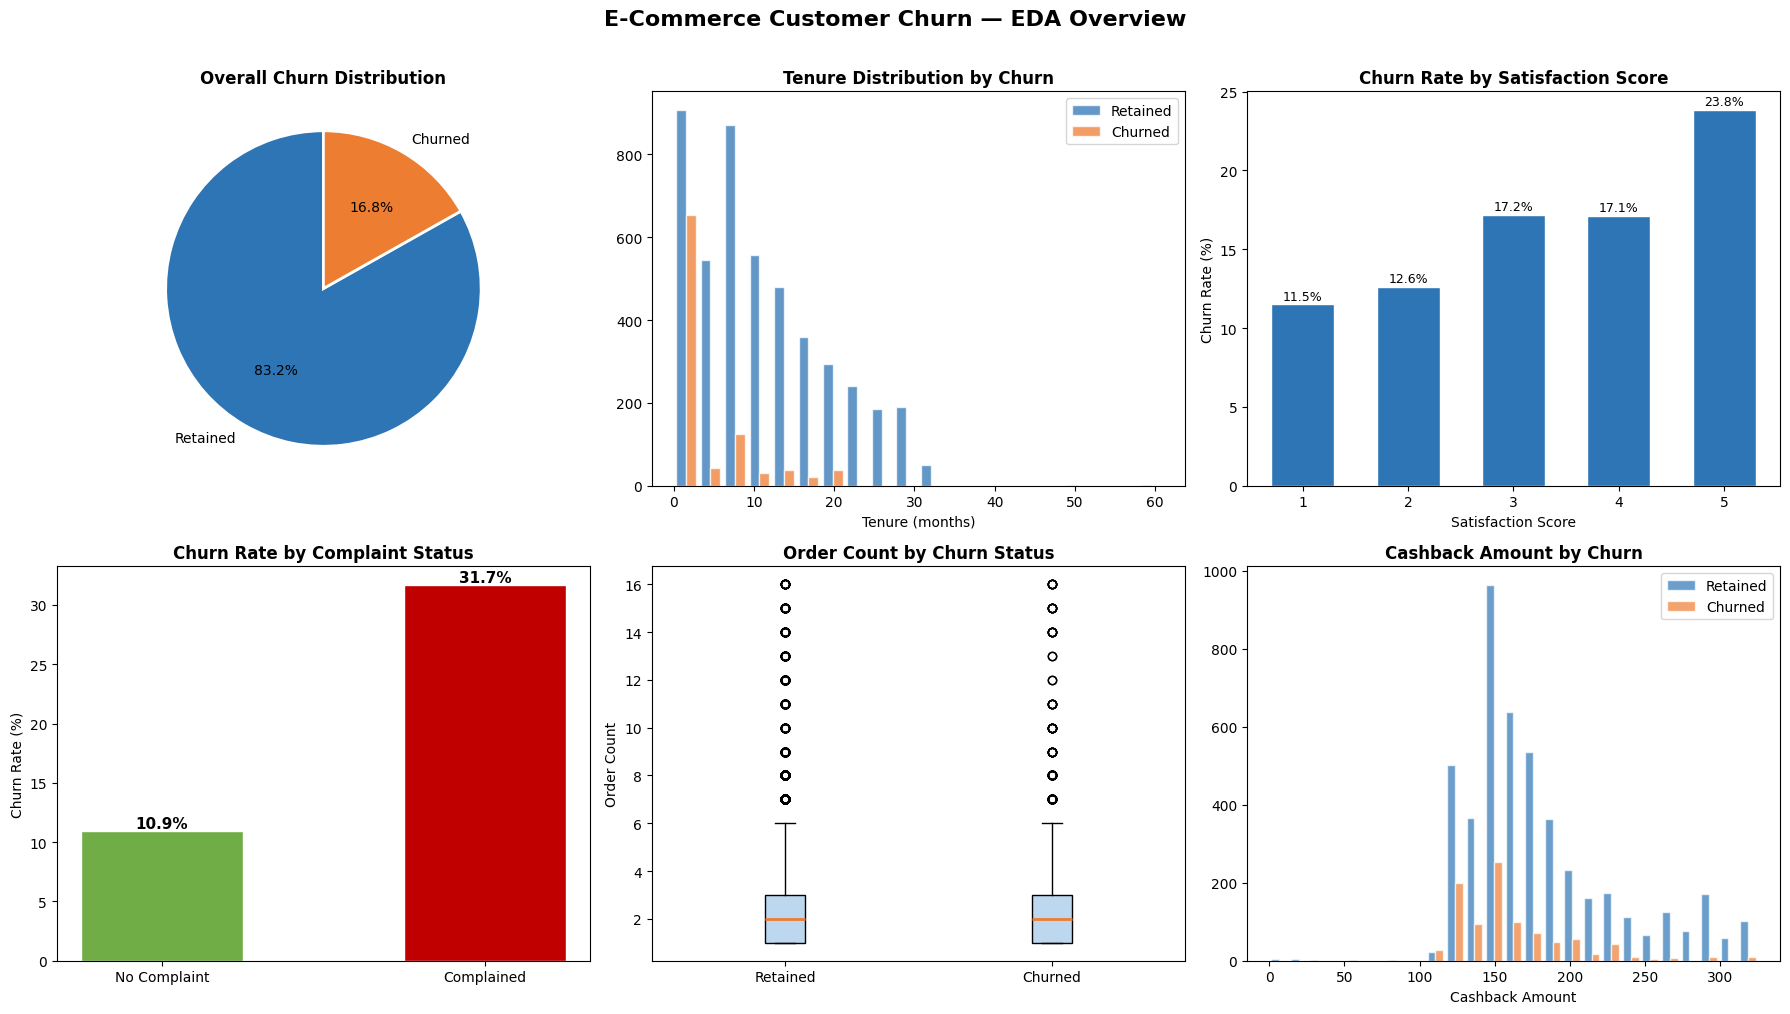

✅ EDA plots saved.


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("E-Commerce Customer Churn — EDA Overview",
             fontsize=16, fontweight='bold', y=1.01)

palette = {0: '#2E75B6', 1: '#ED7D31'}

# 4.1 Churn distribution
churn_counts = df['Churn'].value_counts()
axes[0, 0].pie(
    churn_counts, labels=['Retained', 'Churned'],
    colors=['#2E75B6', '#ED7D31'], autopct='%1.1f%%',
    startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0, 0].set_title('Overall Churn Distribution', fontweight='bold')

# 4.2 Tenure vs Churn
df_plot = df_raw.copy()
df_plot['Tenure'].fillna(df_plot['Tenure'].median(), inplace=True)
axes[0, 1].hist(
    [df_plot[df_plot['Churn']==0]['Tenure'],
     df_plot[df_plot['Churn']==1]['Tenure']],
    bins=20, label=['Retained', 'Churned'],
    color=['#2E75B6', '#ED7D31'], alpha=0.75, edgecolor='white'
)
axes[0, 1].set_title('Tenure Distribution by Churn', fontweight='bold')
axes[0, 1].set_xlabel('Tenure (months)')
axes[0, 1].legend()

# 4.3 Satisfaction Score vs Churn
sat_churn = df_raw.groupby('SatisfactionScore')['Churn'].mean() * 100
axes[0, 2].bar(sat_churn.index, sat_churn.values,
               color='#2E75B6', edgecolor='white', width=0.6)
axes[0, 2].set_title('Churn Rate by Satisfaction Score', fontweight='bold')
axes[0, 2].set_xlabel('Satisfaction Score')
axes[0, 2].set_ylabel('Churn Rate (%)')
for i, v in enumerate(sat_churn.values):
    axes[0, 2].text(sat_churn.index[i], v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

# 4.4 Complain vs Churn
comp = df_raw.groupby('Complain')['Churn'].mean() * 100
axes[1, 0].bar(['No Complaint', 'Complained'], comp.values,
               color=['#70AD47', '#C00000'], edgecolor='white', width=0.5)
axes[1, 0].set_title('Churn Rate by Complaint Status', fontweight='bold')
axes[1, 0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(comp.values):
    axes[1, 0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

# 4.5 Order Count vs Churn
axes[1, 1].boxplot(
    [df_raw[df_raw['Churn']==0]['OrderCount'].dropna(),
     df_raw[df_raw['Churn']==1]['OrderCount'].dropna()],
    labels=['Retained', 'Churned'],
    patch_artist=True,
    boxprops=dict(facecolor='#BDD7EE'),
    medianprops=dict(color='#ED7D31', linewidth=2)
)
axes[1, 1].set_title('Order Count by Churn Status', fontweight='bold')
axes[1, 1].set_ylabel('Order Count')

# 4.6 Cashback Amount vs Churn
axes[1, 2].hist(
    [df_raw[df_raw['Churn']==0]['CashbackAmount'],
     df_raw[df_raw['Churn']==1]['CashbackAmount']],
    bins=25, label=['Retained', 'Churned'],
    color=['#2E75B6', '#ED7D31'], alpha=0.7, edgecolor='white'
)
axes[1, 2].set_title('Cashback Amount by Churn', fontweight='bold')
axes[1, 2].set_xlabel('Cashback Amount')
axes[1, 2].legend()

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved.")

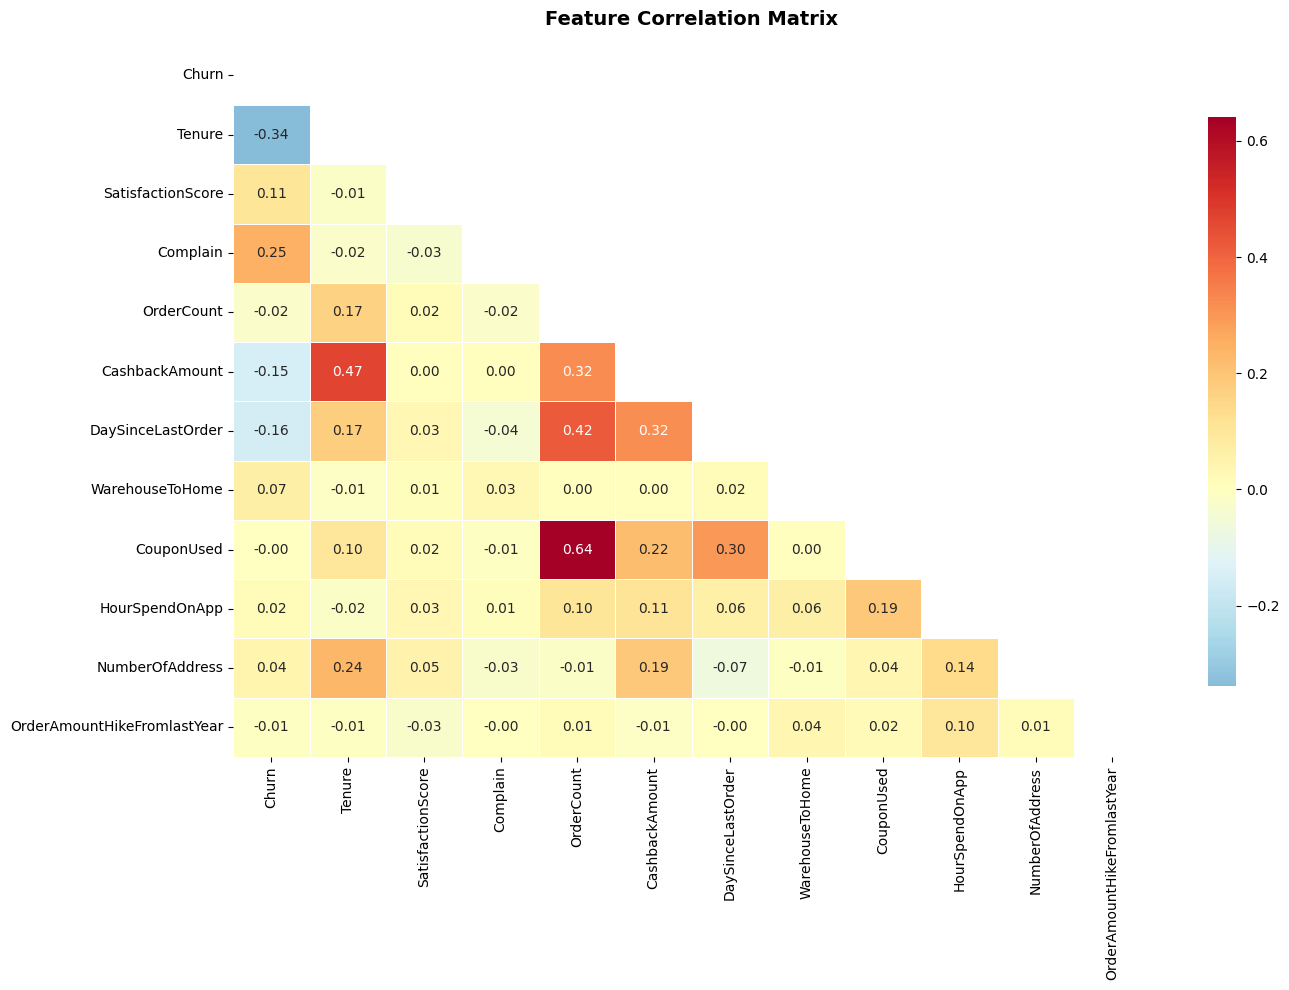

✅ Correlation heatmap saved.


In [ ]:
plt.figure(figsize=(14, 10))
corr_cols = ['Churn', 'Tenure', 'SatisfactionScore', 'Complain',
             'OrderCount', 'CashbackAmount', 'DaySinceLastOrder',
             'WarehouseToHome', 'CouponUsed', 'HourSpendOnApp',
             'NumberOfAddress', 'OrderAmountHikeFromlastYear']
corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Correlation heatmap saved.")


In [ ]:
df_ts = df_raw.copy()
df_ts['Tenure'].fillna(df_ts['Tenure'].median(), inplace=True)
df_ts['Tenure'] = df_ts['Tenure'].astype(int)

# Monthly churn rate and order demand by tenure month
monthly = (df_ts.groupby('Tenure')
           .agg(
               churn_rate=('Churn', 'mean'),
               avg_orders=('OrderCount', 'mean'),
               customer_count=('CustomerID', 'count')
           )
           .reset_index()
           .sort_values('Tenure'))

# Demand signal = avg_orders × (1 - churn_rate) — retained customers ordering
monthly['demand_signal'] = monthly['avg_orders'] * (1 - monthly['churn_rate'])
monthly['demand_signal'].fillna(monthly['demand_signal'].median(), inplace=True)

print("✅ Monthly time series created.")
print(monthly.head(10).to_string(index=False))

✅ Monthly time series created.
 Tenure  churn_rate  avg_orders  customer_count  demand_signal
      0    0.535433    1.889328             508       0.877719
      1    0.505797    2.705968             690       1.337297
      2    0.083832    1.922156             167       1.761017
      3    0.092308    2.420213             195       2.196809
      4    0.098522    3.174359             203       2.861614
      5    0.078431    3.060914             204       2.820842
      6    0.043716    2.752809             183       2.632468
      7    0.072398    2.773148             221       2.572377
      8    0.060837    2.946360             263       2.767114
      9    0.181996    2.098814             511       1.716838


/tmp/ipykernel_624/2267121306.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ts['Tenure'].fillna(df_ts['Tenure'].median(), inplace=True)
/tmp/ipykernel_624/2267121306.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace

In [ ]:
series = monthly['demand_signal'].values
months = monthly['Tenure'].values

# Moving Average windows
window_3  = pd.Series(series).rolling(window=3,  min_periods=1).mean().values
window_5  = pd.Series(series).rolling(window=5,  min_periods=1).mean().values
window_7  = pd.Series(series).rolling(window=7,  min_periods=1).mean().values

def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

def mae(actual, predicted):
    return np.mean(np.abs(actual - predicted))

def mape(actual, predicted):
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

ma3_rmse  = rmse(series, window_3)
ma5_rmse  = rmse(series, window_5)
ma7_rmse  = rmse(series, window_7)

print(f"\n📊 Moving Average — RMSE Comparison")
print(f"   MA(3):  RMSE = {ma3_rmse:.4f}")
print(f"   MA(5):  RMSE = {ma5_rmse:.4f}")
print(f"   MA(7):  RMSE = {ma7_rmse:.4f}")

best_ma_window = min([(ma3_rmse, 3, window_3), (ma5_rmse, 5, window_5),
                      (ma7_rmse, 7, window_7)], key=lambda x: x[0])
print(f"   ✅ Best MA window: MA({best_ma_window[1]}) with RMSE={best_ma_window[0]:.4f}")



📊 Moving Average — RMSE Comparison
   MA(3):  RMSE = 0.4508
   MA(5):  RMSE = 0.6008
   MA(7):  RMSE = 0.6646
   ✅ Best MA window: MA(3) with RMSE=0.4508


In [ ]:
alphas = [0.2, 0.4, 0.6, 0.8]
ses_results = {}

for alpha in alphas:
    model = SimpleExpSmoothing(series, initialization_method='estimated')
    fit   = model.fit(smoothing_level=alpha, optimized=False)
    fitted_vals = fit.fittedvalues
    ses_results[alpha] = {
        'fitted': fitted_vals,
        'rmse': rmse(series, fitted_vals),
        'mae':  mae(series, fitted_vals),
        'mape': mape(series, fitted_vals)
    }

# Also run with auto-optimized alpha
model_opt = SimpleExpSmoothing(series, initialization_method='estimated')
fit_opt   = model_opt.fit(optimized=True)
opt_alpha = fit_opt.params['smoothing_level']
ses_results['opt'] = {
    'fitted': fit_opt.fittedvalues,
    'rmse':   rmse(series, fit_opt.fittedvalues),
    'mae':    mae(series, fit_opt.fittedvalues),
    'mape':   mape(series, fit_opt.fittedvalues),
    'alpha':  opt_alpha
}

print(f"\n📊 SES — RMSE by Alpha")
for a, res in ses_results.items():
    label = f"α={a:.2f}" if a != 'opt' else f"α=auto({opt_alpha:.3f})"
    print(f"   SES {label}:  RMSE={res['rmse']:.4f}  MAE={res['mae']:.4f}  MAPE={res['mape']:.2f}%")

best_ses = min(ses_results.items(), key=lambda x: x[1]['rmse'])
print(f"   ✅ Best SES: alpha={best_ses[0]} with RMSE={best_ses[1]['rmse']:.4f}")



📊 SES — RMSE by Alpha
   SES α=0.20:  RMSE=0.8171  MAE=0.6607  MAPE=28.23%
   SES α=0.40:  RMSE=0.7242  MAE=0.5204  MAPE=23.39%
   SES α=0.60:  RMSE=0.7157  MAE=0.5175  MAPE=23.13%
   SES α=0.80:  RMSE=0.7480  MAE=0.5543  MAPE=24.63%
   SES α=auto(0.539):  RMSE=0.7127  MAE=0.5065  MAPE=22.50%
   ✅ Best SES: alpha=opt with RMSE=0.7127


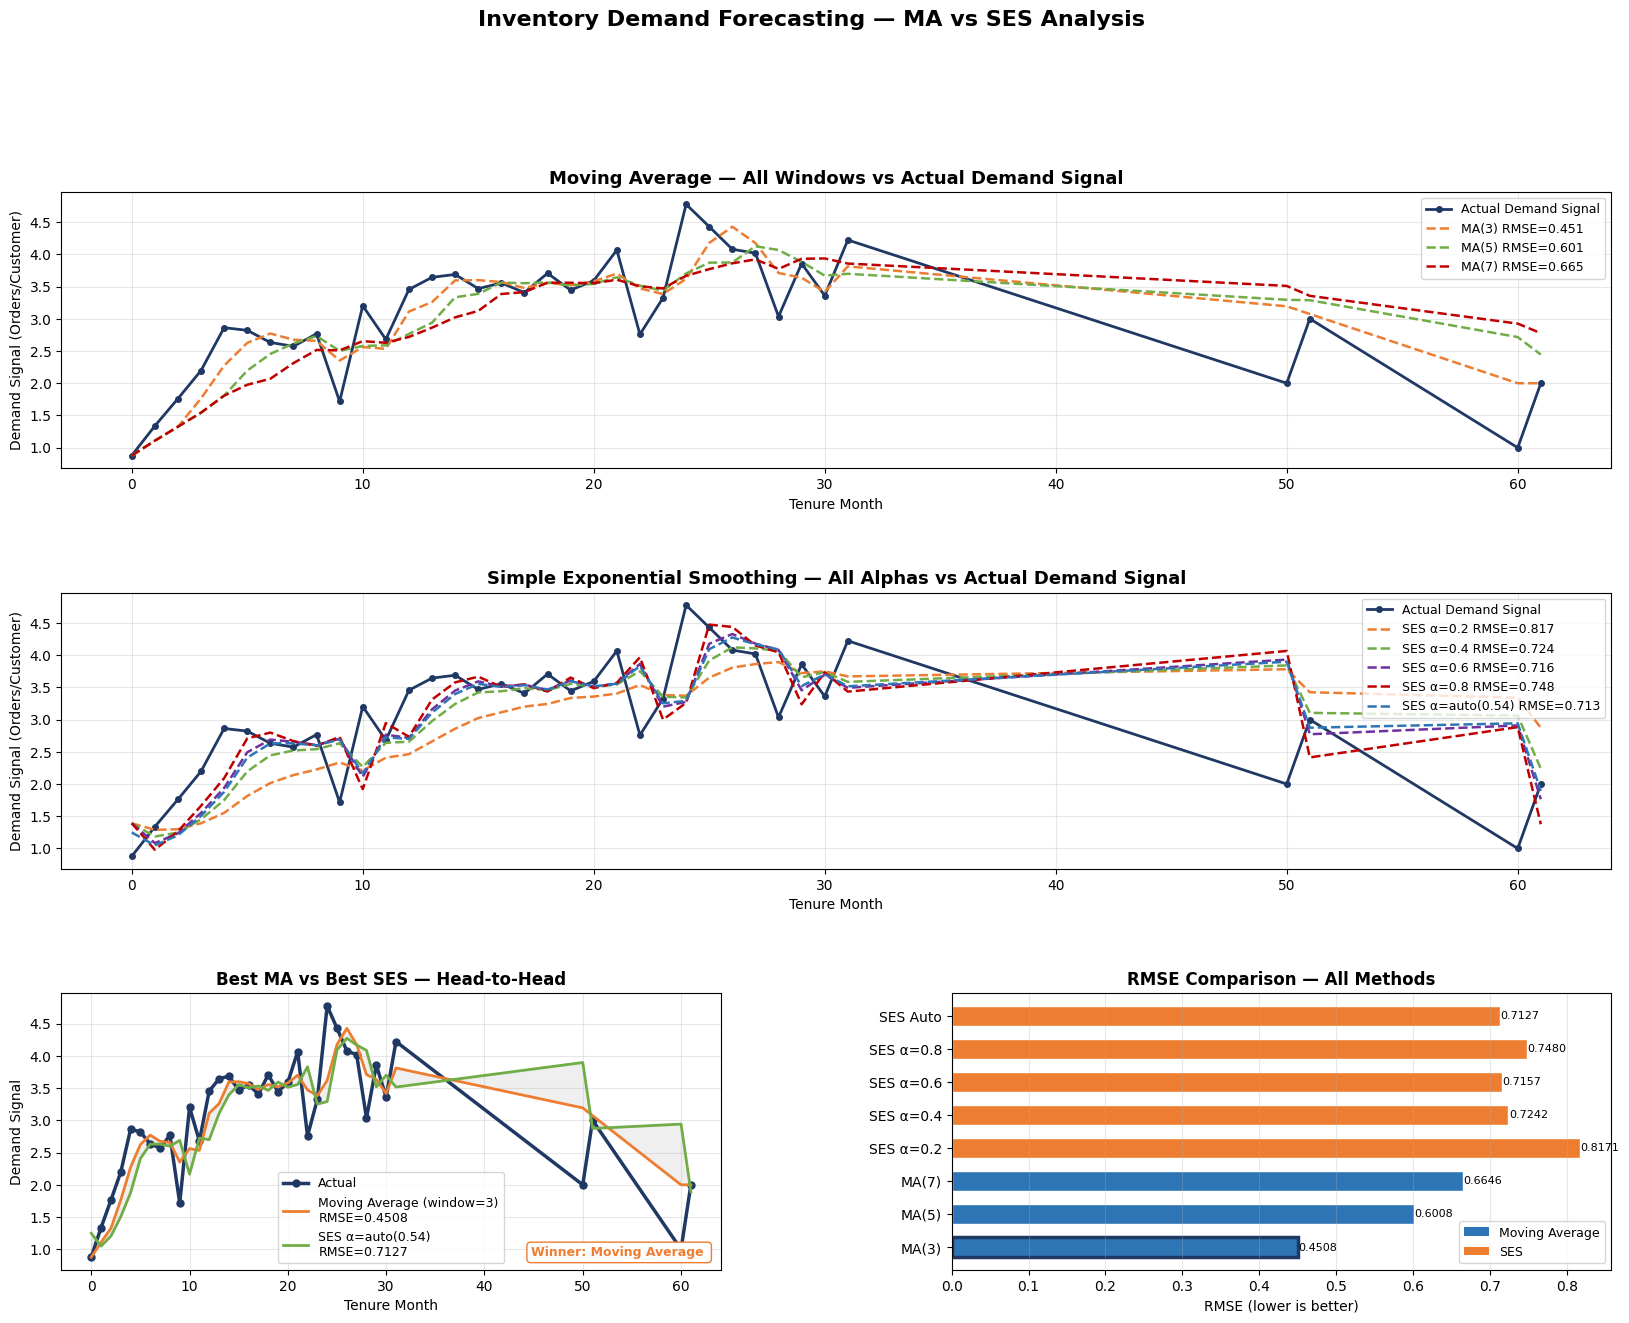

✅ MA vs SES comparison chart saved.


In [ ]:
best_ses_fitted = best_ses[1]['fitted']
best_ses_rmse   = best_ses[1]['rmse']
best_ses_label  = f"SES α=auto({opt_alpha:.2f})" if best_ses[0]=='opt' else f"SES α={best_ses[0]}"

best_ma_fitted  = best_ma_window[2]
best_ma_rmse    = best_ma_window[0]
best_ma_label   = f"Moving Average (window={best_ma_window[1]})"

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# --- Plot A: MA all windows ---
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(months, series, 'o-', color='#1F3864', lw=2, ms=4, label='Actual Demand Signal')
ax1.plot(months, window_3, '--', color='#ED7D31', lw=1.8, label=f'MA(3) RMSE={ma3_rmse:.3f}')
ax1.plot(months, window_5, '--', color='#70AD47', lw=1.8, label=f'MA(5) RMSE={ma5_rmse:.3f}')
ax1.plot(months, window_7, '--', color='#C00000', lw=1.8, label=f'MA(7) RMSE={ma7_rmse:.3f}')
ax1.set_title('Moving Average — All Windows vs Actual Demand Signal',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Tenure Month')
ax1.set_ylabel('Demand Signal (Orders/Customer)')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Plot B: SES alphas ---
ax2 = fig.add_subplot(gs[1, :])
ax2.plot(months, series, 'o-', color='#1F3864', lw=2, ms=4, label='Actual Demand Signal')
ses_colors = ['#ED7D31', '#70AD47', '#7030A0', '#C00000', '#2E75B6']
for i, (a, res) in enumerate(ses_results.items()):
    lbl = f"α=auto({opt_alpha:.2f}) RMSE={res['rmse']:.3f}" if a=='opt' else f"α={a} RMSE={res['rmse']:.3f}"
    ax2.plot(months, res['fitted'], '--', color=ses_colors[i], lw=1.8, label=f'SES {lbl}')
ax2.set_title('Simple Exponential Smoothing — All Alphas vs Actual Demand Signal',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Tenure Month')
ax2.set_ylabel('Demand Signal (Orders/Customer)')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

# --- Plot C: Best MA vs Best SES head-to-head ---
ax3 = fig.add_subplot(gs[2, 0])
ax3.plot(months, series, 'o-', color='#1F3864', lw=2.5, ms=5, label='Actual')
ax3.plot(months, best_ma_fitted, '-', color='#ED7D31', lw=2, label=f'{best_ma_label}\nRMSE={best_ma_rmse:.4f}')
ax3.plot(months, best_ses_fitted, '-', color='#70AD47', lw=2, label=f'{best_ses_label}\nRMSE={best_ses_rmse:.4f}')
ax3.fill_between(months, best_ma_fitted, best_ses_fitted, alpha=0.12, color='gray')
ax3.set_title('Best MA vs Best SES — Head-to-Head', fontsize=12, fontweight='bold')
ax3.set_xlabel('Tenure Month')
ax3.set_ylabel('Demand Signal')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

winner = best_ma_label if best_ma_rmse < best_ses_rmse else best_ses_label
win_color = '#ED7D31' if best_ma_rmse < best_ses_rmse else '#70AD47'
ax3.text(0.98, 0.05, f'Winner: {winner.split("(")[0]}',
         transform=ax3.transAxes, fontsize=9, color=win_color,
         fontweight='bold', ha='right',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=win_color))

# --- Plot D: RMSE Bar Comparison ---
ax4 = fig.add_subplot(gs[2, 1])
methods  = [f'MA(3)', f'MA(5)', f'MA(7)', 'SES α=0.2', 'SES α=0.4', 'SES α=0.6', 'SES α=0.8', 'SES Auto']
rmse_vals = [ma3_rmse, ma5_rmse, ma7_rmse] + [ses_results[a]['rmse'] for a in alphas] + [ses_results['opt']['rmse']]
colors_bar = ['#2E75B6']*3 + ['#ED7D31']*5
bars = ax4.barh(methods, rmse_vals, color=colors_bar, edgecolor='white', height=0.6)
ax4.set_title('RMSE Comparison — All Methods', fontsize=12, fontweight='bold')
ax4.set_xlabel('RMSE (lower is better)')
for bar, val in zip(bars, rmse_vals):
    ax4.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=8)
best_idx = rmse_vals.index(min(rmse_vals))
bars[best_idx].set_edgecolor('#1F3864')
bars[best_idx].set_linewidth(2.5)
ax4.grid(True, axis='x', alpha=0.3)

# Legend patch
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2E75B6', label='Moving Average'),
                   Patch(facecolor='#ED7D31', label='SES')]
ax4.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.suptitle('Inventory Demand Forecasting — MA vs SES Analysis',
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('ma_vs_ses_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ MA vs SES comparison chart saved.")

In [ ]:
FEATURES = ['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp',
            'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress',
            'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed',
            'OrderCount', 'DaySinceLastOrder', 'CashbackAmount',
            'PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
            'PreferedOrderCat', 'MaritalStatus']

X = df[FEATURES]
y = df['Churn']

# Train/test split (stratified to preserve churn ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Handle class imbalance with SMOTE (production best practice)
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"   Before SMOTE — Churn: {y_train.sum()} | Non-churn: {(y_train==0).sum()}")
print(f"   After  SMOTE — Churn: {y_train_bal.sum()} | Non-churn: {(y_train_bal==0).sum()}")

# Feature scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_bal)
X_test_sc  = scaler.transform(X_test)

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
lr_model.fit(X_train_sc, y_train_bal)

y_pred      = lr_model.predict(X_test_sc)
y_pred_prob = lr_model.predict_proba(X_test_sc)[:, 1]

# Metrics
acc    = accuracy_score(y_test, y_pred)
f1     = f1_score(y_test, y_pred)
f1_w   = f1_score(y_test, y_pred, average='weighted')
auc_sc = roc_auc_score(y_test, y_pred_prob)

print(f"\n📊 Logistic Regression — Churn Prediction Results")
print(f"   Accuracy        : {acc*100:.2f}%")
print(f"   F1-Score (binary)   : {f1:.4f}")
print(f"   F1-Score (weighted) : {f1_w:.4f}")
print(f"   ROC-AUC         : {auc_sc:.4f}")
print(f"\n   Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

   Before SMOTE — Churn: 711 | Non-churn: 3511
   After  SMOTE — Churn: 3511 | Non-churn: 3511

📊 Logistic Regression — Churn Prediction Results
   Accuracy        : 74.22%
   F1-Score (binary)   : 0.5088
   F1-Score (weighted) : 0.7720
   ROC-AUC         : 0.8347

   Classification Report:

              precision    recall  f1-score   support

    Retained       0.95      0.73      0.83      1171
     Churned       0.37      0.79      0.51       237

    accuracy                           0.74      1408
   macro avg       0.66      0.76      0.67      1408
weighted avg       0.85      0.74      0.77      1408



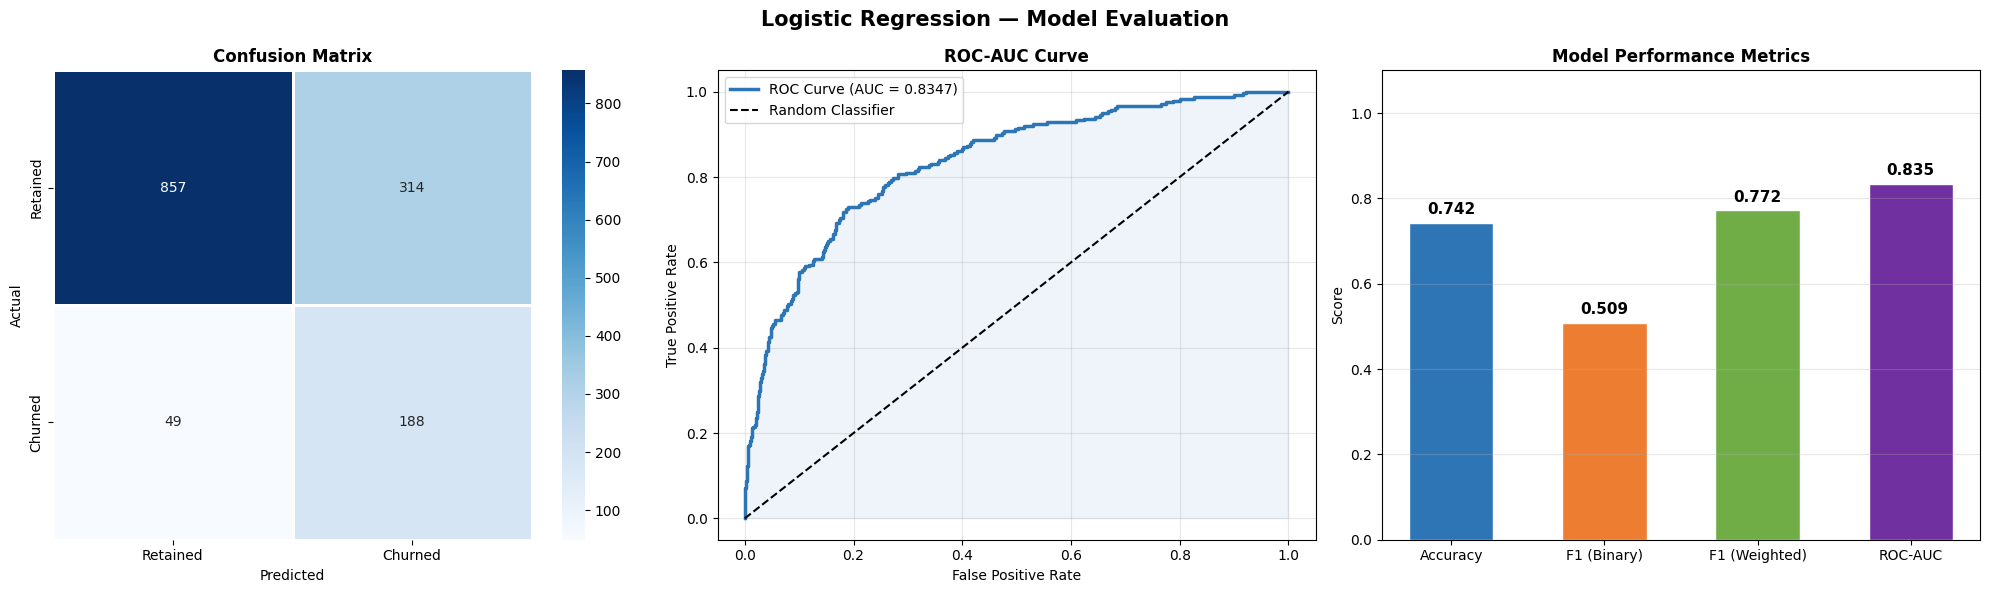

✅ Model evaluation plots saved.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Logistic Regression — Model Evaluation', fontsize=15, fontweight='bold')

# 11.1 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'],
            linewidths=1, linecolor='white')
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# 11.2 ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='#2E75B6', lw=2.5,
             label=f'ROC Curve (AUC = {auc_sc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.08, color='#2E75B6')
axes[1].set_title('ROC-AUC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# 11.3 Metrics Bar Chart
metric_names = ['Accuracy', 'F1 (Binary)', 'F1 (Weighted)', 'ROC-AUC']
metric_vals  = [acc, f1, f1_w, auc_sc]
bars = axes[2].bar(metric_names, metric_vals,
                   color=['#2E75B6', '#ED7D31', '#70AD47', '#7030A0'],
                   edgecolor='white', width=0.55)
axes[2].set_ylim(0, 1.1)
axes[2].set_title('Model Performance Metrics', fontweight='bold')
axes[2].set_ylabel('Score')
for bar, val in zip(bars, metric_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
axes[2].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('logistic_regression_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model evaluation plots saved.")


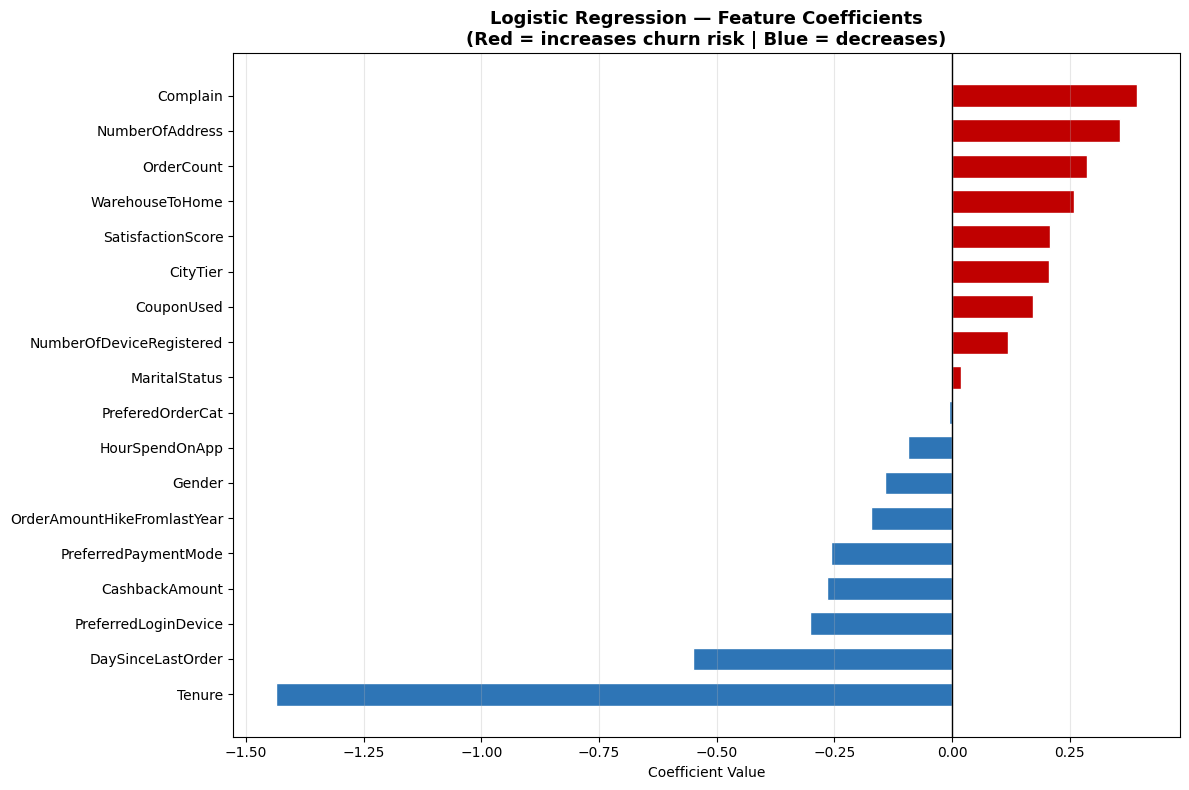

✅ Feature importance chart saved.


In [ ]:
coef_df = pd.DataFrame({
    'Feature':     FEATURES,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=True)

plt.figure(figsize=(12, 8))
colors = ['#C00000' if c > 0 else '#2E75B6' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'],
         color=colors, edgecolor='white', height=0.65)
plt.axvline(0, color='black', linewidth=1)
plt.title('Logistic Regression — Feature Coefficients\n(Red = increases churn risk | Blue = decreases)',
          fontsize=13, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance chart saved.")

In [ ]:
X_test_orig = X_test.copy()
X_test_orig['ChurnProbability'] = y_pred_prob
X_test_orig['Tenure_raw']       = X_test_orig['Tenure']

tenure_demand = (
    X_test_orig
    .groupby('Tenure_raw')
    .agg(
        avg_churn_prob=('ChurnProbability', 'mean'),
        avg_orders    =('OrderCount',       'mean'),
        n_customers   =('ChurnProbability', 'count')
    )
    .reset_index()
    .sort_values('Tenure_raw')
)

# Expected active customers (1 - churn probability)
tenure_demand['retention_rate']       = 1 - tenure_demand['avg_churn_prob']
tenure_demand['expected_active']      = tenure_demand['n_customers'] * tenure_demand['retention_rate']
tenure_demand['inventory_demand']     = tenure_demand['expected_active'] * tenure_demand['avg_orders']

# Apply best SES to smooth the inventory demand
raw_demand = tenure_demand['inventory_demand'].values
ses_inv    = SimpleExpSmoothing(raw_demand, initialization_method='estimated')
ses_fit    = ses_inv.fit(optimized=True)
tenure_demand['smoothed_demand_SES'] = ses_fit.fittedvalues

# Apply best MA
tenure_demand['smoothed_demand_MA'] = (
    pd.Series(raw_demand)
    .rolling(window=best_ma_window[1], min_periods=1)
    .mean()
    .values
)

# Safety stock (20% buffer — production standard)
tenure_demand['safety_stock_SES'] = tenure_demand['smoothed_demand_SES'] * 1.20
tenure_demand['safety_stock_MA']  = tenure_demand['smoothed_demand_MA']  * 1.20

print("✅ Inventory Planning Table (first 10 tenure months):")
display_cols = ['Tenure_raw', 'n_customers', 'avg_churn_prob', 'retention_rate',
                'inventory_demand', 'smoothed_demand_SES', 'smoothed_demand_MA',
                'safety_stock_SES']
print(tenure_demand[display_cols].head(10).round(2).to_string(index=False))


✅ Inventory Planning Table (first 10 tenure months):
 Tenure_raw  n_customers  avg_churn_prob  retention_rate  inventory_demand  smoothed_demand_SES  smoothed_demand_MA  safety_stock_SES
        0.0          125            0.72            0.28             63.67                75.40               63.67             90.48
        1.0          161            0.73            0.27            120.10                70.38               91.89             84.46
        2.0           48            0.60            0.40             38.89                91.65               74.22            109.98
        3.0           47            0.56            0.44             51.97                69.08               70.32             82.90
        4.0           69            0.56            0.44             87.73                61.77               59.53             74.12
        5.0           50            0.47            0.53             84.92                72.87               74.87             87.45
        6

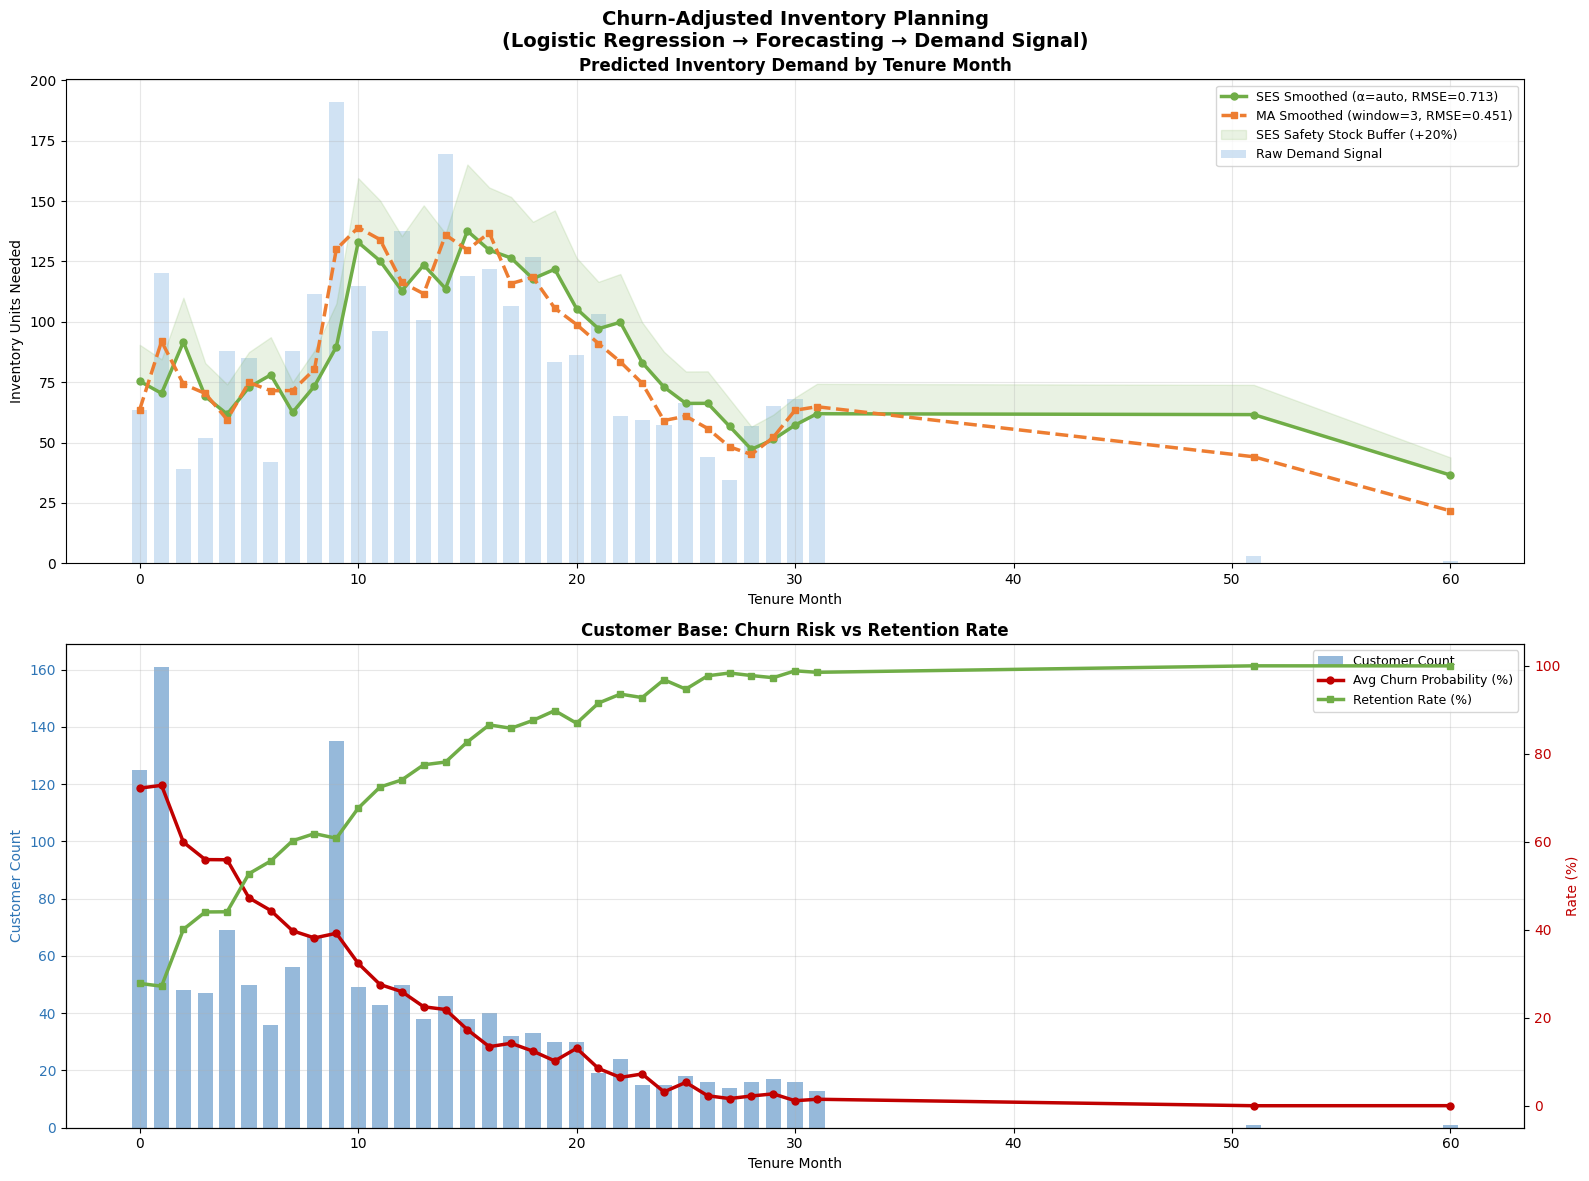

✅ Inventory planning chart saved.


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('Churn-Adjusted Inventory Planning\n(Logistic Regression → Forecasting → Demand Signal)',
             fontsize=14, fontweight='bold')

x = tenure_demand['Tenure_raw'].values

# Chart 1: Raw vs Smoothed Demand
axes[0].bar(x, tenure_demand['inventory_demand'], color='#BDD7EE',
            alpha=0.7, label='Raw Demand Signal', width=0.7)
axes[0].plot(x, tenure_demand['smoothed_demand_SES'], 'o-',
             color='#70AD47', lw=2.5, ms=5, label=f'SES Smoothed (α=auto, RMSE={best_ses_rmse:.3f})')
axes[0].plot(x, tenure_demand['smoothed_demand_MA'], 's--',
             color='#ED7D31', lw=2.5, ms=5, label=f'MA Smoothed (window={best_ma_window[1]}, RMSE={best_ma_rmse:.3f})')
axes[0].fill_between(x, tenure_demand['smoothed_demand_SES'],
                     tenure_demand['safety_stock_SES'],
                     alpha=0.15, color='#70AD47', label='SES Safety Stock Buffer (+20%)')
axes[0].set_title('Predicted Inventory Demand by Tenure Month', fontweight='bold')
axes[0].set_xlabel('Tenure Month')
axes[0].set_ylabel('Inventory Units Needed')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Chart 2: Churn Probability & Retention Rate
ax2b = axes[1].twinx()
axes[1].bar(x, tenure_demand['n_customers'], color='#2E75B6',
            alpha=0.5, label='Customer Count', width=0.7)
ax2b.plot(x, tenure_demand['avg_churn_prob'] * 100, 'o-',
          color='#C00000', lw=2.5, ms=5, label='Avg Churn Probability (%)')
ax2b.plot(x, tenure_demand['retention_rate'] * 100, 's-',
          color='#70AD47', lw=2.5, ms=5, label='Retention Rate (%)')
axes[1].set_title('Customer Base: Churn Risk vs Retention Rate', fontweight='bold')
axes[1].set_xlabel('Tenure Month')
axes[1].set_ylabel('Customer Count', color='#2E75B6')
ax2b.set_ylabel('Rate (%)', color='#C00000')
axes[1].tick_params(axis='y', labelcolor='#2E75B6')
ax2b.tick_params(axis='y', labelcolor='#C00000')
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('inventory_planning_output.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Inventory planning chart saved.")

In [ ]:
print("\n" + "="*65)
print("   INVENTORY PLANNING — PROJECT SUMMARY REPORT")
print("="*65)

print("\n📦 DATASET")
print(f"   Total Customers : {len(df_raw):,}")
print(f"   Churned         : {df_raw['Churn'].sum():,}  ({df_raw['Churn'].mean()*100:.1f}%)")
print(f"   Retained        : {(df_raw['Churn']==0).sum():,}  ({(1-df_raw['Churn'].mean())*100:.1f}%)")

print("\n📈 FORECASTING RESULTS")
print(f"   Best Moving Average : MA(window={best_ma_window[1]})  →  RMSE = {best_ma_rmse:.4f}")
print(f"   Best SES            : α={opt_alpha:.3f} (auto)     →  RMSE = {best_ses_rmse:.4f}")
if best_ses_rmse < best_ma_rmse:
    diff = best_ma_rmse - best_ses_rmse
    print(f"   🏆 WINNER: SES is better by {diff:.4f} RMSE")
    print(f"   Recommendation: Use SES for inventory demand smoothing in production.")
else:
    diff = best_ses_rmse - best_ma_rmse
    print(f"   🏆 WINNER: Moving Average is better by {diff:.4f} RMSE")
    print(f"   Recommendation: Use MA(window={best_ma_window[1]}) for inventory smoothing in production.")

print("\n🤖 LOGISTIC REGRESSION — CHURN PREDICTION")
print(f"   Accuracy          : {acc*100:.2f}%")
print(f"   F1-Score (Binary) : {f1:.4f}")
print(f"   F1-Score (Weighted): {f1_w:.4f}")
print(f"   ROC-AUC           : {auc_sc:.4f}")

print("\n📦 INVENTORY PLANNING (Latest Tenure Month)")
last = tenure_demand.iloc[-1]
print(f"   Customers at Risk    : {last['n_customers']:.0f}")
print(f"   Avg Churn Probability: {last['avg_churn_prob']*100:.1f}%")
print(f"   Expected Retention   : {last['retention_rate']*100:.1f}%")
print(f"   Raw Demand Signal    : {last['inventory_demand']:.1f} units")
print(f"   SES Smoothed Demand  : {last['smoothed_demand_SES']:.1f} units")
print(f"   Safety Stock (SES)   : {last['safety_stock_SES']:.1f} units (+20% buffer)")

print("\n📁 OUTPUT FILES SAVED:")
print("   eda_overview.png                — EDA charts")
print("   correlation_heatmap.png         — Feature correlations")
print("   ma_vs_ses_comparison.png        — MA vs SES forecasting")
print("   logistic_regression_evaluation.png — Model metrics")
print("   feature_coefficients.png        — Feature importance")
print("   inventory_planning_output.png   — Final inventory plan")
print("\n" + "="*65)
print("✅ Project complete. All outputs ready for production review.")
print("="*65)


   INVENTORY PLANNING — PROJECT SUMMARY REPORT

📦 DATASET
   Total Customers : 5,630
   Churned         : 948  (16.8%)
   Retained        : 4,682  (83.2%)

📈 FORECASTING RESULTS
   Best Moving Average : MA(window=3)  →  RMSE = 0.4508
   Best SES            : α=0.539 (auto)     →  RMSE = 0.7127
   🏆 WINNER: Moving Average is better by 0.2620 RMSE
   Recommendation: Use MA(window=3) for inventory smoothing in production.

🤖 LOGISTIC REGRESSION — CHURN PREDICTION
   Accuracy          : 74.22%
   F1-Score (Binary) : 0.5088
   F1-Score (Weighted): 0.7720
   ROC-AUC           : 0.8347

📦 INVENTORY PLANNING (Latest Tenure Month)
   Customers at Risk    : 1
   Avg Churn Probability: 0.0%
   Expected Retention   : 100.0%
   Raw Demand Signal    : 1.0 units
   SES Smoothed Demand  : 36.5 units
   Safety Stock (SES)   : 43.8 units (+20% buffer)

📁 OUTPUT FILES SAVED:
   eda_overview.png                — EDA charts
   correlation_heatmap.png         — Feature correlations
   ma_vs_ses_comparison.